# 02 L1B Waveform Feature Extraction

## Purpose and boundary

This notebook demonstrates waveform feature extraction on selected sweeps/tracks. Components shown here are candidate/prominent waveform diagnostics, not official returns. The goal is to tune robust features, not to maximize peak count.

In [1]:
from pathlib import Path
import sys

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_casals_l1b_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "waveform_components.py").exists():
            return candidate
        if (candidate / "CASALS_L1B" / "waveform_components.py").exists():
            return candidate / "CASALS_L1B"
    raise FileNotFoundError("Could not locate CASALS_L1B directory from the current notebook working directory.")


CASALS_L1B_DIR = find_casals_l1b_root()
if str(CASALS_L1B_DIR) not in sys.path:
    sys.path.insert(0, str(CASALS_L1B_DIR))

from waveform_components import (
    build_record_index_grid,
    classify_prominent_components,
    compute_fixed_bin_stripe_features,
    detect_candidate_components_1d,
    read_optional_1d,
    read_sweep_matrix,
    safe_argmax_bin,
    summarize_pulse_waveform_features,
)

H5_PATH = CASALS_L1B_DIR / "casals_h5_downloads" / "casals_l1b_20241118T171757_001_02.h5"
SWEEP_IDX = 5000
assert H5_PATH.exists(), H5_PATH

PARAMETER_PRESETS = {
    "loose": {
        "background_mode": "minus_bg_mean",
        "clip_negative_after_background": True,
        "smoothing_method": "savgol",
        "smoothing_window": 7,
        "smoothing_polyorder": 2,
        "min_height_sigma": 2.0,
        "min_prominence_sigma": 2.5,
        "min_width_bins": 1.0,
        "max_width_bins": 100.0,
        "min_distance_bins": 3,
        "max_candidate_components_per_pulse": 10,
        "min_prominent_prominence_sigma": 3.0,
        "min_prominent_relative_to_main": 0.10,
        "min_secondary_separation_bins": 5,
        "broad_main_width_bins": 30.0,
        "weak_main_prominence_sigma": 3.5,
        "edge_exclusion_bins": 5,
        "exclude_edge_components": True,
    },
    "default": {
        "background_mode": "minus_bg_mean",
        "clip_negative_after_background": True,
        "smoothing_method": "savgol",
        "smoothing_window": 7,
        "smoothing_polyorder": 2,
        "min_height_sigma": 3.0,
        "min_prominence_sigma": 4.0,
        "min_width_bins": 1.0,
        "max_width_bins": 80.0,
        "min_distance_bins": 5,
        "max_candidate_components_per_pulse": 8,
        "min_prominent_prominence_sigma": 5.0,
        "min_prominent_relative_to_main": 0.20,
        "min_secondary_separation_bins": 8,
        "broad_main_width_bins": 30.0,
        "weak_main_prominence_sigma": 4.0,
        "edge_exclusion_bins": 10,
        "exclude_edge_components": True,
    },
    "strict": {
        "background_mode": "minus_bg_mean",
        "clip_negative_after_background": True,
        "smoothing_method": "savgol",
        "smoothing_window": 9,
        "smoothing_polyorder": 2,
        "min_height_sigma": 4.0,
        "min_prominence_sigma": 5.0,
        "min_width_bins": 1.5,
        "max_width_bins": 60.0,
        "min_distance_bins": 7,
        "max_candidate_components_per_pulse": 6,
        "min_prominent_prominence_sigma": 6.0,
        "min_prominent_relative_to_main": 0.25,
        "min_secondary_separation_bins": 10,
        "broad_main_width_bins": 25.0,
        "weak_main_prominence_sigma": 5.0,
        "edge_exclusion_bins": 12,
        "exclude_edge_components": True,
    },
}

In [2]:
with h5py.File(H5_PATH, "r") as h5:
    index_info = build_record_index_grid(h5)
    rx_matrix, valid_tracks, record_indices = read_sweep_matrix(h5, "rx_waveform", SWEEP_IDX, index_info)
    fields = {
        name: read_optional_1d(h5, name, index_info.n_records, dtype=(bool if name == "good_snr" else np.float64))
        for name in ["refh_snr", "good_snr", "bg_mean", "bg_std", "refh_thres", "refh_amp"]
    }

def extract_track_diagnostics(track_num: int, config: dict) -> dict:
    pulse_index = int(record_indices[track_num])
    y_raw = rx_matrix[track_num].astype(np.float64)
    candidates = detect_candidate_components_1d(
        y_raw=y_raw,
        bg_mean=float(fields["bg_mean"][pulse_index]),
        bg_std=float(fields["bg_std"][pulse_index]),
        refh_thres=float(fields["refh_thres"][pulse_index]),
        config=config,
    )
    components = classify_prominent_components(candidates, config)
    raw_bin, raw_amp = safe_argmax_bin(y_raw)
    corrected = y_raw - float(fields["bg_mean"][pulse_index])
    corrected_bin, corrected_amp = safe_argmax_bin(corrected)
    summary = summarize_pulse_waveform_features(
        components=components,
        raw_argmax_bin=raw_bin,
        corrected_argmax_bin=corrected_bin,
        refh_amp=float(fields["refh_amp"][pulse_index]),
        refh_snr=float(fields["refh_snr"][pulse_index]),
        good_snr=bool(fields["good_snr"][pulse_index]),
        bg_mean=float(fields["bg_mean"][pulse_index]),
        bg_std=float(fields["bg_std"][pulse_index]),
        config=config,
    )
    return {
        "track_num": track_num,
        "pulse_index": pulse_index,
        "raw_waveform": y_raw,
        "processed_waveform": corrected,
        "components": components,
        "summary": summary,
        "refh_snr": float(fields["refh_snr"][pulse_index]),
        "good_snr": bool(fields["good_snr"][pulse_index]),
        "raw_argmax_bin": raw_bin,
        "raw_argmax_amp": raw_amp,
        "corrected_argmax_bin": corrected_bin,
        "corrected_argmax_amp": corrected_amp,
    }

default_track_diagnostics = [extract_track_diagnostics(track_num, PARAMETER_PRESETS["default"]) for track_num in valid_tracks]
default_df = pd.DataFrame(
    {
        "track_num": [item["track_num"] for item in default_track_diagnostics],
        "pulse_index": [item["pulse_index"] for item in default_track_diagnostics],
        "refh_snr": [item["refh_snr"] for item in default_track_diagnostics],
        "good_snr": [item["good_snr"] for item in default_track_diagnostics],
        "n_candidate_components": [item["summary"]["n_candidate_components"] for item in default_track_diagnostics],
        "n_prominent_components": [item["summary"]["n_prominent_components"] for item in default_track_diagnostics],
        "n_valid_secondary_components": [item["summary"]["n_valid_secondary_components"] for item in default_track_diagnostics],
        "main_peak_bin": [item["summary"]["main_peak_bin"] for item in default_track_diagnostics],
        "main_peak_width_bins": [item["summary"]["main_peak_width_bins"] for item in default_track_diagnostics],
        "secondary_to_main_prominence_ratio": [item["summary"]["secondary_to_main_prominence_ratio"] for item in default_track_diagnostics],
        "waveform_reliability_class": [item["summary"]["waveform_reliability_class"] for item in default_track_diagnostics],
    }
)
stripe_features = compute_fixed_bin_stripe_features(
    track=default_df["track_num"].to_numpy(dtype=np.float64),
    peak_bin=default_df["main_peak_bin"].to_numpy(dtype=np.float64),
    bin_tolerance=2,
    min_fraction=0.20,
)
display(default_df.head())
display(pd.Series(stripe_features, name="value").to_frame())

,track_num,pulse_index,refh_snr,good_snr,n_candidate_components,n_prominent_components,n_valid_secondary_components,main_peak_bin,main_peak_width_bins,secondary_to_main_prominence_ratio,waveform_reliability_class
0,0,1280000,2.958109,False,5,2,1,1694.0,6.325945,0.981655,clear_main_with_secondary_candidate
1,1,1280032,2.434548,False,4,1,0,1678.0,20.129588,NaN,ambiguous_main_peak
2,2,1280064,2.583749,False,5,2,1,1672.0,21.093457,0.733333,clear_main_with_secondary_candidate
3,3,1280096,2.204402,False,8,3,2,2297.0,6.470296,0.964574,clear_main_with_secondary_candidate
4,4,1280128,2.120193,False,6,1,0,1655.0,15.437619,NaN,ambiguous_main_peak


,value
fixed_bin_mode,1693.0
fixed_bin_fraction,0.378906
fixed_bin_band_min,1691.0
fixed_bin_band_max,1695.0
stripe_like_flag,True


## Load H5 and choose representative tracks

In [3]:
representative_rows = []
used_tracks = set()

def pick_row(frame: pd.DataFrame, reason: str) -> None:
    if frame.empty:
        return
    row = frame.iloc[0]
    if int(row["track_num"]) in used_tracks:
        return
    representative_rows.append({"reason": reason, **row.to_dict()})
    used_tracks.add(int(row["track_num"]))

pick_row(default_df.sort_values("refh_snr", ascending=False), "high refh_snr")
pick_row(default_df.sort_values("refh_snr", ascending=True), "low refh_snr")
pick_row(default_df.sort_values("main_peak_width_bins", ascending=False), "broad peak")

mode_bin = stripe_features["fixed_bin_mode"]
if np.isfinite(mode_bin):
    stripe_frame = default_df.assign(mode_distance=np.abs(default_df["main_peak_bin"] - mode_bin)).sort_values(["mode_distance", "refh_snr"], ascending=[True, True])
    pick_row(stripe_frame, "suspected stripe/fixed-bin peak")

secondary_frame = default_df.sort_values("secondary_to_main_prominence_ratio", ascending=False)
pick_row(secondary_frame, "multi-peak candidate")

representative_df = pd.DataFrame(representative_rows)
selected_tracks_for_panels = representative_df["track_num"].astype(int).tolist()
display(representative_df[[
    "reason", "track_num", "pulse_index", "refh_snr", "good_snr",
    "n_candidate_components", "n_prominent_components", "main_peak_width_bins",
    "secondary_to_main_prominence_ratio", "waveform_reliability_class"
]])

,reason,track_num,pulse_index,refh_snr,good_snr,n_candidate_components,n_prominent_components,main_peak_width_bins,secondary_to_main_prominence_ratio,waveform_reliability_class
0,high refh_snr,245,1280190,16.682180,True,2,1,8.406826,NaN,clear_main_peak
1,low refh_snr,188,1280151,1.565499,False,1,1,6.264887,NaN,ambiguous_main_peak
2,broad peak,55,1280230,1.813438,False,4,1,28.662342,NaN,ambiguous_main_peak
3,suspected stripe/fixed-bin peak,138,1280081,1.733839,False,4,1,6.140175,NaN,ambiguous_main_peak
4,multi-peak candidate,82,1280074,2.524770,False,5,4,5.832267,0.997294,clear_main_with_secondary_candidate


## Single waveform panels

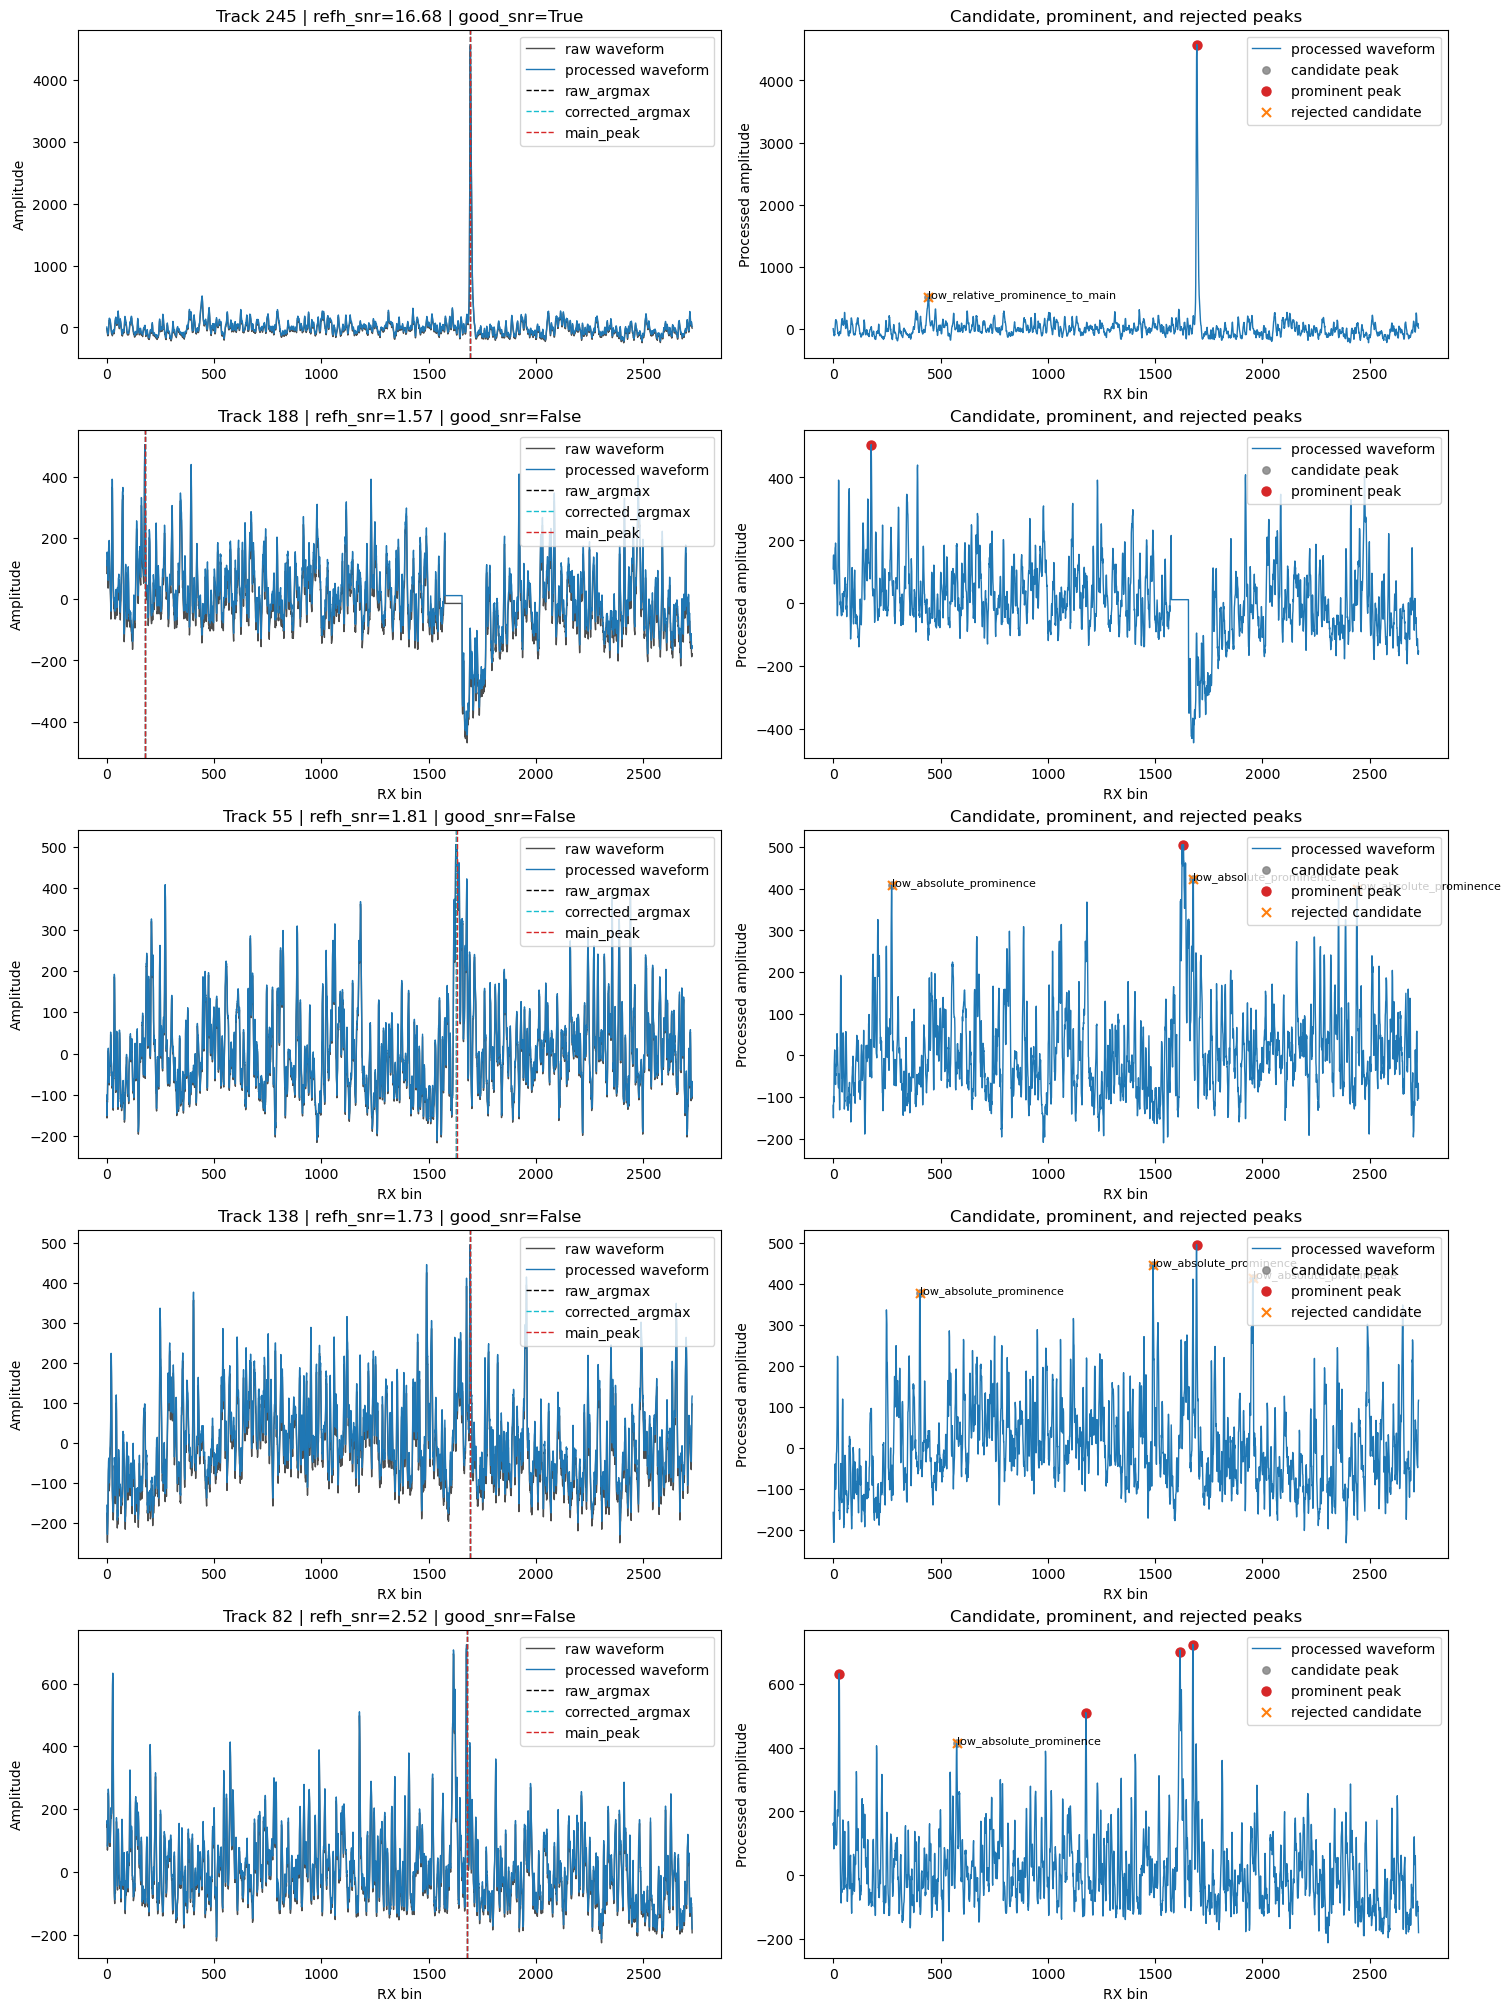

In [4]:
n_rows = len(selected_tracks_for_panels)
fig, axes = plt.subplots(n_rows, 2, figsize=(15, 4 * n_rows), constrained_layout=True)
axes = np.atleast_2d(axes)

for row_idx, track_num in enumerate(selected_tracks_for_panels):
    diag = next(item for item in default_track_diagnostics if item["track_num"] == track_num)
    components = diag["components"]
    candidates = components
    prominent = [item for item in components if item["is_prominent_component"]]
    rejected = [item for item in components if not item["is_prominent_component"]]
    raw = diag["raw_waveform"]
    processed = diag["processed_waveform"]

    ax = axes[row_idx, 0]
    ax.plot(raw, color="0.3", linewidth=1.0, label="raw waveform")
    ax.plot(processed, color="tab:blue", linewidth=1.0, label="processed waveform")
    ax.axvline(diag["raw_argmax_bin"], color="black", linestyle="--", linewidth=1.0, label="raw_argmax")
    ax.axvline(diag["corrected_argmax_bin"], color="tab:cyan", linestyle="--", linewidth=1.0, label="corrected_argmax")
    ax.axvline(diag["summary"]["main_peak_bin"], color="tab:red", linestyle="--", linewidth=1.0, label="main_peak")
    ax.set_title(
        f"Track {track_num} | refh_snr={diag['refh_snr']:.2f} | good_snr={diag['good_snr']}"
    )
    ax.set_xlabel("RX bin")
    ax.set_ylabel("Amplitude")
    ax.legend(loc="upper right")

    ax = axes[row_idx, 1]
    ax.plot(processed, color="tab:blue", linewidth=1.0, label="processed waveform")
    for comp in candidates:
        ax.scatter(comp["peak_bin"], comp["amplitude_processed"], s=28, color="tab:gray", alpha=0.8, label="candidate peak" if comp["rank_by_prominence"] == 1 else None)
    for comp in prominent:
        ax.scatter(comp["peak_bin"], comp["amplitude_processed"], s=42, color="tab:red", label="prominent peak" if comp["rank_by_prominence"] == 1 else None)
    for comp in rejected:
        ax.scatter(comp["peak_bin"], comp["amplitude_processed"], marker="x", s=42, color="tab:orange", label="rejected candidate" if comp["rank_by_prominence"] == rejected[0]["rank_by_prominence"] else None)
        ax.text(comp["peak_bin"], comp["amplitude_processed"], comp["rejected_reason"], fontsize=8)
    ax.set_title("Candidate, prominent, and rejected peaks")
    ax.set_xlabel("RX bin")
    ax.set_ylabel("Processed amplitude")
    ax.legend(loc="upper right")

plt.show()

## Parameter sensitivity

,preset,track_num,n_candidate_components,n_prominent_components,main_peak_bin,secondary_to_main_prominence_ratio
0,loose,245,10,2,1694.0,0.113302
1,loose,188,10,9,177.0,0.893698
2,loose,55,10,10,1632.0,0.799406
3,loose,138,10,10,1693.0,0.874573
4,loose,82,10,10,1676.0,0.997294
5,default,245,2,1,1694.0,NaN
6,default,188,1,1,177.0,NaN
7,default,55,4,1,1632.0,NaN
8,default,138,4,1,1693.0,NaN
9,default,82,5,4,1676.0,0.997294


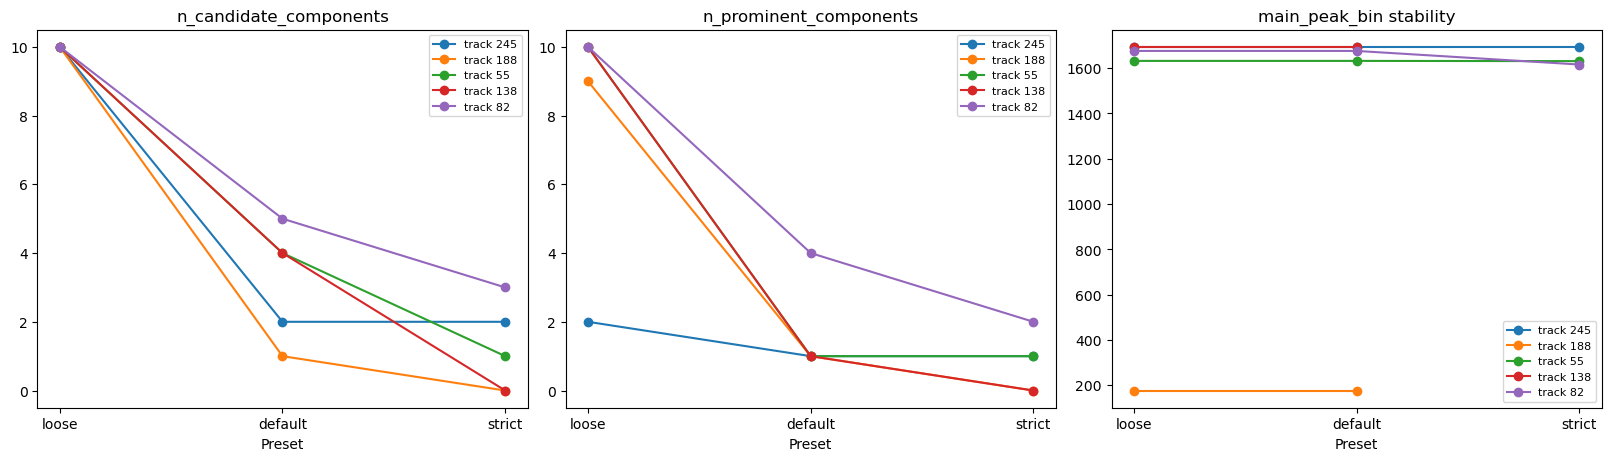

In [5]:
sensitivity_rows = []
for preset_name, preset_cfg in PARAMETER_PRESETS.items():
    for track_num in selected_tracks_for_panels:
        diag = extract_track_diagnostics(track_num, preset_cfg)
        sensitivity_rows.append(
            {
                "preset": preset_name,
                "track_num": track_num,
                "n_candidate_components": diag["summary"]["n_candidate_components"],
                "n_prominent_components": diag["summary"]["n_prominent_components"],
                "main_peak_bin": diag["summary"]["main_peak_bin"],
                "secondary_to_main_prominence_ratio": diag["summary"]["secondary_to_main_prominence_ratio"],
            }
        )

sensitivity_df = pd.DataFrame(sensitivity_rows)
display(sensitivity_df)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)
for track_num in selected_tracks_for_panels:
    subset = sensitivity_df[sensitivity_df["track_num"] == track_num]
    axes[0].plot(subset["preset"], subset["n_candidate_components"], marker="o", label=f"track {track_num}")
    axes[1].plot(subset["preset"], subset["n_prominent_components"], marker="o", label=f"track {track_num}")
    axes[2].plot(subset["preset"], subset["main_peak_bin"], marker="o", label=f"track {track_num}")
axes[0].set_title("n_candidate_components")
axes[1].set_title("n_prominent_components")
axes[2].set_title("main_peak_bin stability")
for ax in axes:
    ax.set_xlabel("Preset")
    ax.legend(loc="best", fontsize=8)
plt.show()

## Sweep matrix section

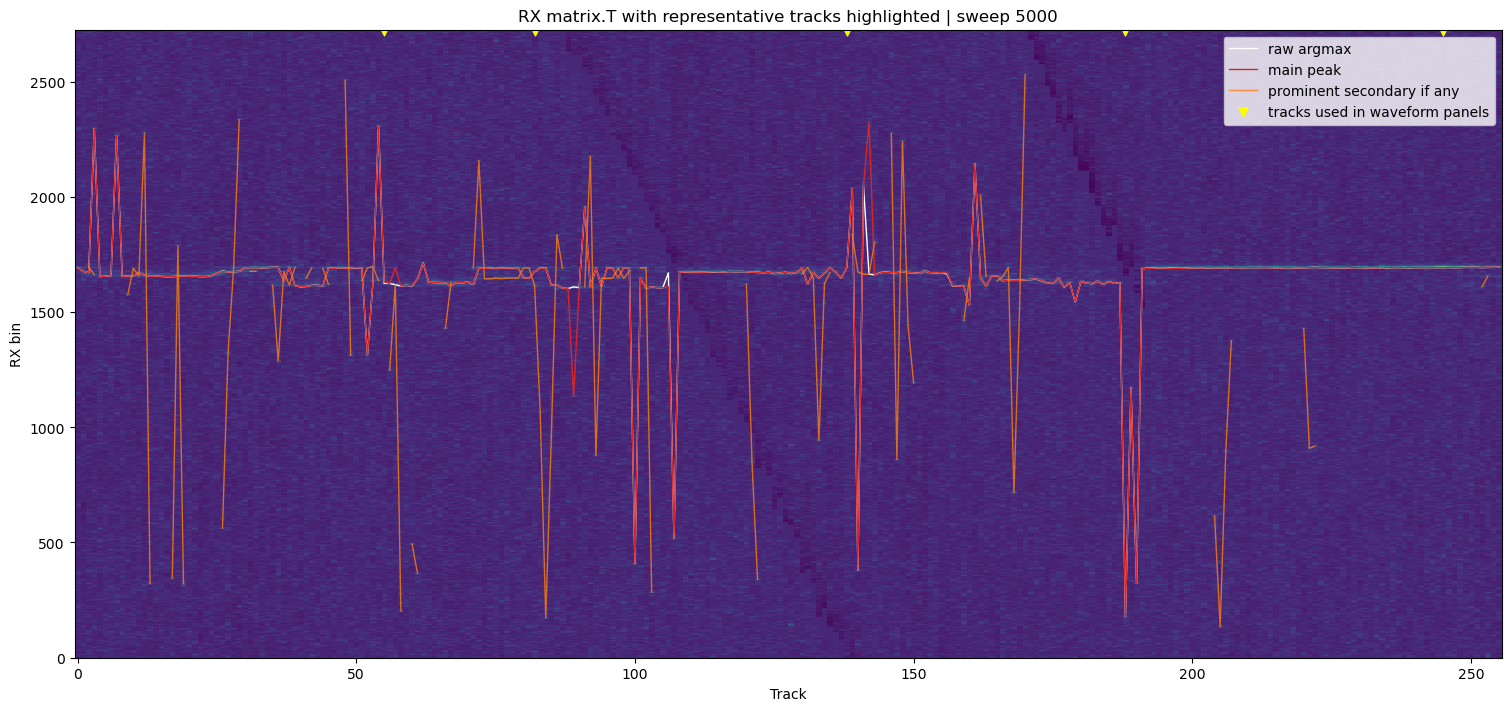

In [6]:
main_peak_overlay = np.full(index_info.n_tracks, np.nan, dtype=np.float64)
secondary_peak_overlay = np.full(index_info.n_tracks, np.nan, dtype=np.float64)
for item in default_track_diagnostics:
    main_peak_overlay[item["track_num"]] = item["summary"]["main_peak_bin"]
    if item["summary"]["has_valid_secondary_peak"]:
        secondary_peak_overlay[item["track_num"]] = item["summary"]["secondary_peak_bin"]

raw_argmax_overlay = np.array([safe_argmax_bin(row)[0] for row in rx_matrix], dtype=np.float64)

fig, ax = plt.subplots(figsize=(15, 7), constrained_layout=True)
ax.imshow(rx_matrix.T, aspect="auto", origin="lower", cmap="viridis", interpolation="nearest")
ax.plot(np.arange(index_info.n_tracks), raw_argmax_overlay, color="white", linewidth=1.0, label="raw argmax")
ax.plot(np.arange(index_info.n_tracks), main_peak_overlay, color="tab:red", linewidth=1.0, label="main peak")
ax.plot(np.arange(index_info.n_tracks), secondary_peak_overlay, color="tab:orange", linewidth=1.0, alpha=0.8, label="prominent secondary if any")
ax.scatter(selected_tracks_for_panels, np.full(len(selected_tracks_for_panels), rx_matrix.shape[1] - 5), marker="v", s=40, color="yellow", label="tracks used in waveform panels")
ax.set_title(f"RX matrix.T with representative tracks highlighted | sweep {SWEEP_IDX}")
ax.set_xlabel("Track")
ax.set_ylabel("RX bin")
ax.legend(loc="upper right")
plt.show()

## Interpretation

- Stable features: main peak prominence, main peak width, and main peak bin under default/strict settings.
- Sensitive features: raw candidate count and weak secondary detections under loose settings.
- Recommended batch setting: default or strict. Loose settings over-detect and should not be used for scientific summaries.